# NoticeLens RAG Experiment Lab

> **Understand the IRS notice in front of you — with evidence.**

NoticeLens uses official IRS notice guidance to explain uploaded IRS notices with grounded evidence.

**Research question:** *How should IRS guidance be chunked and retrieved so NoticeLens can locate the correct evidence section reliably?*

This notebook is an artifact-only experiment narrative. It reads the approved CSV and JSON reports; it does not implement or invoke the production RAG pipeline.


In [1]:
from pathlib import Path
import json
import math
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NETWORK_ATTEMPTS = []
_SOCKET_AUDIT_EVENTS = frozenset({"socket" + ".connect", "socket" + ".getaddrinfo"})

def _deny_external_network(
    event, args, _events=_SOCKET_AUDIT_EVENTS, _attempts=NETWORK_ATTEMPTS
):
    if event in _events:
        _attempts.append(event)
        raise RuntimeError("External network access is disabled for this artifact-only notebook.")

sys.addaudithook(_deny_external_network)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "corpus_manifest.csv").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "data" / "corpus_manifest.csv").is_file(), "Run this notebook from the project root or notebooks directory."

ARTIFACT_READS = []

def load_json(relative_path):
    path = PROJECT_ROOT / relative_path
    assert path.is_file(), f"Missing frozen artifact: {relative_path}"
    ARTIFACT_READS.append(relative_path)
    return json.loads(path.read_text(encoding="utf-8"))

def load_csv(relative_path):
    path = PROJECT_ROOT / relative_path
    assert path.is_file(), f"Missing frozen artifact: {relative_path}"
    ARTIFACT_READS.append(relative_path)
    return pd.read_csv(path, encoding="utf-8")

print(f"Artifact-only notebook root: {PROJECT_ROOT}")
print("External provider clients imported: 0")


Artifact-only notebook root: C:\Users\donur\OneDrive\Desktop\Agentic AI gen academy\Noticelens
External provider clients imported: 0


## 2. Corpus

The permanent knowledge base contains only official IRS guidance pages. The manifest below provides the document identity, notice family, source URL, heading audit, and frozen content hash for each page.


In [2]:
corpus = load_csv("data/corpus_manifest.csv")
assert len(corpus) == 50
assert corpus["source_origin"].eq("IRS").all()

family_distribution = (
    corpus.groupby("notice_family", as_index=False)
    .size()
    .rename(columns={"size": "document_count"})
    .sort_values(["document_count", "notice_family"], ascending=[False, True])
    .reset_index(drop=True)
)
assert family_distribution["notice_family"].nunique() == 17
assert family_distribution["document_count"].sum() == 50

display(pd.DataFrame({
    "Corpus measure": ["IRS guidance documents", "Unique notice families"],
    "Value": [len(corpus), family_distribution["notice_family"].nunique()],
}))
display(family_distribution)
display(corpus[["doc_id", "notice_code", "notice_family", "title", "source_origin"]].head(5))


,Corpus measure,Value
0,IRS guidance documents,50
1,Unique notice families,17


,notice_family,document_count
0,identity_security,7
1,non_filer,7
2,balance_collection,5
3,business_return_adjustment,5
4,return_adjustment,5
5,levy_cdp,3
6,return_review,3
7,underreporter_deficiency,3
8,credit_eligibility,2
9,installment_agreement,2


,doc_id,notice_code,notice_family,title,source_origin
0,irs_cp01,CP01,identity_security,Understanding your CP01 notice,IRS
1,irs_cp01a,CP01A,identity_security,Understanding your CP01A notice,IRS
2,irs_cp01c,CP01C,identity_security,Understanding your CP01C notice,IRS
3,irs_cp01e,CP01E,identity_security,Understanding your CP01E notice,IRS
4,irs_cp01h,CP01H,identity_security,Understanding your CP01H notice,IRS


## 3. Initial Dense Retrieval Experiment

Our initial hypothesis was that semantically similar IRS notices might confuse dense retrieval. The frozen evaluation did not support that hypothesis — dense retrieval already identified the correct notice at rank 1 for every scored document-level question.

**This is a null result:** the proposed document-identity weakness was not observed, so added document-level retrieval complexity was not justified.


In [3]:
phase3_chunk_audit = load_json("reports/phase3_chunk_audit.json")
phase3_results = load_json("reports/phase3_baseline_results.json")

phase3_overall = phase3_results["metrics"]["notice_retrieval"]["overall"]
phase3_summary = pd.DataFrame({
    "Measure": [
        "Source documents",
        "Fixed chunks",
        "Chunking",
        "Notice Precision@1",
        "MRR",
        "Hit@5",
        "Hypothesis outcome",
    ],
    "Value": [
        phase3_chunk_audit["inputs"]["source_document_count"],
        phase3_chunk_audit["total_chunks"],
        f'{phase3_chunk_audit["chunker"]["target_tokens"]} tokens / {phase3_chunk_audit["chunker"]["overlap_tokens"]} overlap',
        f'{phase3_overall["precision_at_1"]:.1%}',
        f'{phase3_overall["mrr"]:.3f}',
        f'{phase3_overall["hit_at_5"]:.1%}',
        "NULL RESULT",
    ],
})
display(phase3_summary)

assert phase3_chunk_audit["inputs"]["source_document_count"] == 50
assert phase3_chunk_audit["total_chunks"] == 350
assert phase3_chunk_audit["chunker"]["target_tokens"] == 220
assert phase3_chunk_audit["chunker"]["overlap_tokens"] == 40
assert phase3_overall["precision_at_1"] == 1.0
assert phase3_overall["mrr"] == 1.0
assert phase3_overall["hit_at_5"] == 1.0


,Measure,Value
0,Source documents,50
1,Fixed chunks,350
2,Chunking,220 tokens / 40 overlap
3,Notice Precision@1,100.0%
4,MRR,1.000
5,Hit@5,100.0%
6,Hypothesis outcome,NULL RESULT


## 4. Section-Level Weakness

Although the correct notice was retrieved reliably, arbitrary fixed-size chunks often mixed multiple IRS sections together. This reduced precision when the user needed a specific section of guidance.


In [4]:
phase4_fixed_map = load_json("reports/phase4_fixed_chunk_section_map.json")
phase4_fixed_results = load_json("reports/phase4_fixed_section_results.json")

fixed_metrics = phase4_fixed_results["metrics"]["section_retrieval"]["overall"]
fixed_map_summary = phase4_fixed_map["summary"]

display(pd.DataFrame({
    "Measure": [
        "Fixed Section Precision@1",
        "Section MRR",
        "Section Hit@5",
        "Fixed chunks crossing multiple heading paths",
    ],
    "Value": [
        f'{fixed_metrics["section_precision_at_1"]:.1%}',
        f'{fixed_metrics["section_mrr"]:.4f}',
        f'{fixed_metrics["section_hit_at_5"]:.1%}',
        f'{fixed_map_summary["multi_heading_path_chunk_count"]} / {fixed_map_summary["chunk_count"]}',
    ],
}))

assert math.isclose(fixed_metrics["section_precision_at_1"], 0.80)
assert math.isclose(fixed_metrics["section_mrr"], 0.8688888888888889)
assert fixed_metrics["section_hit_at_5"] == 1.0
assert fixed_map_summary["multi_heading_path_chunk_count"] == 302
assert fixed_map_summary["chunk_count"] == 350


,Measure,Value
0,Fixed Section Precision@1,80.0%
1,Section MRR,0.8689
2,Section Hit@5,100.0%
3,Fixed chunks crossing multiple heading paths,302 / 350


## 5. Heading-Aware Chunking

The second strategy respected IRS heading boundaries. Each nonempty section became its own evidence unit; only oversized sections were split with the frozen 220-token / 40-token-overlap rule.


In [5]:
phase4b_chunk_audit = load_json("reports/phase4b_chunk_audit.json")
phase4b_results = load_json("reports/phase4b_heading_results.json")

heading_metrics = phase4b_results["metrics"]["heading_aware_section_retrieval"]["overall"]
direct_comparison = phase4b_results["direct_comparison"]
threshold = phase4b_results["precommitted_thresholds"]["meaningful_p1_gain_absolute_percentage_points"]
improvement_pp = 100 * (
    heading_metrics["section_precision_at_1"] - fixed_metrics["section_precision_at_1"]
)

display(pd.DataFrame({
    "Measure": [
        "Heading-aware chunks",
        "Cross-heading chunks",
        "Section Precision@1",
        "Section MRR",
        "Section Hit@5",
        "Absolute Precision@1 improvement",
        "Precommitted success threshold",
        "Threshold result",
    ],
    "Value": [
        phase4b_chunk_audit["total_heading_aware_chunks"],
        phase4b_chunk_audit["integrity"]["chunks_crossing_heading_boundaries"]["count"],
        f'{heading_metrics["section_precision_at_1"]:.2%}',
        f'{heading_metrics["section_mrr"]:.5f}',
        f'{heading_metrics["section_hit_at_5"]:.1%}',
        f"+{improvement_pp:.2f} percentage points",
        f"≥{threshold} percentage points",
        "MET",
    ],
}))

assert phase4b_chunk_audit["total_heading_aware_chunks"] == 580
assert phase4b_chunk_audit["integrity"]["chunks_crossing_heading_boundaries"]["count"] == 0
assert math.isclose(heading_metrics["section_precision_at_1"], 14 / 15)
assert math.isclose(heading_metrics["section_mrr"], 0.9555555555555555)
assert heading_metrics["section_hit_at_5"] == 1.0
assert math.isclose(improvement_pp, 13.33333333333333)
assert direct_comparison["retain_heading_aware_based_on_precommitted_evidence"] is True
assert improvement_pp >= threshold


,Measure,Value
0,Heading-aware chunks,580
1,Cross-heading chunks,0
2,Section Precision@1,93.33%
3,Section MRR,0.95556
4,Section Hit@5,100.0%
5,Absolute Precision@1 improvement,+13.33 percentage points
6,Precommitted success threshold,≥10 percentage points
7,Threshold result,MET


## 6. Visual Comparison

The table and chart compare the two frozen section-retrieval strategies on the same 15-question benchmark.


,Strategy,Section Precision@1,MRR,Hit@5
0,Fixed,80.00%,0.86889,100.0%
1,Heading-aware,93.33%,0.95556,100.0%


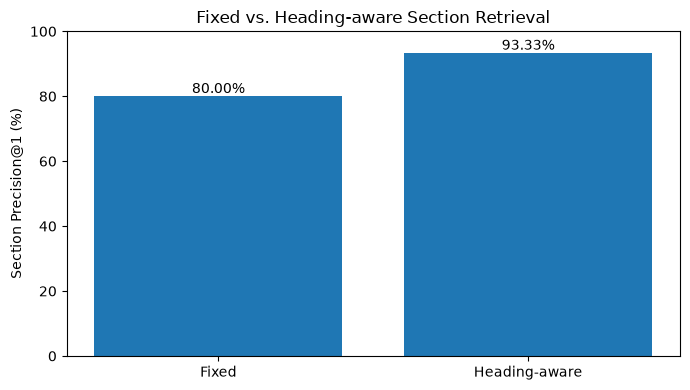

In [6]:
strategy_comparison = pd.DataFrame({
    "Strategy": ["Fixed", "Heading-aware"],
    "Section Precision@1": [
        fixed_metrics["section_precision_at_1"],
        heading_metrics["section_precision_at_1"],
    ],
    "MRR": [fixed_metrics["section_mrr"], heading_metrics["section_mrr"]],
    "Hit@5": [fixed_metrics["section_hit_at_5"], heading_metrics["section_hit_at_5"]],
})
comparison_display = strategy_comparison.copy()
comparison_display["Section Precision@1"] = comparison_display["Section Precision@1"].map(lambda value: f"{value:.2%}")
comparison_display["MRR"] = comparison_display["MRR"].map(lambda value: f"{value:.5f}")
comparison_display["Hit@5"] = comparison_display["Hit@5"].map(lambda value: f"{value:.1%}")
display(comparison_display)

fig, ax = plt.subplots(figsize=(7, 4))
values = 100 * strategy_comparison["Section Precision@1"]
bars = ax.bar(strategy_comparison["Strategy"], values)
ax.set_ylabel("Section Precision@1 (%)")
ax.set_title("Fixed vs. Heading-aware Section Retrieval")
ax.set_ylim(0, 100)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.2f}%", ha="center")
plt.tight_layout()
plt.show()


## 7. Real Retrieval Examples

Three target sections moved to rank 1, while one query regressed. The aggregate optimization succeeded, but it did not improve every individual query.


In [7]:
paired = load_csv("reports/phase4b_comparison.csv").set_index("question_id")
expected_examples = {
    "S03": {"notice": "CP503", "fixed": 2, "heading": 1, "classification": "IMPROVED"},
    "S07": {"notice": "CP2000", "fixed": 5, "heading": 1, "classification": "IMPROVED"},
    "S11": {"notice": "CP59", "fixed": 3, "heading": 1, "classification": "IMPROVED"},
    "S06": {"notice": "CP2501", "fixed": 1, "heading": 3, "classification": "REGRESSED"},
}
example_rows = []
for question_id, expected in expected_examples.items():
    observed = paired.loc[question_id]
    assert int(observed["fixed_rank"]) == expected["fixed"]
    assert int(observed["heading_aware_rank"]) == expected["heading"]
    assert observed["classification"] == expected["classification"]
    assert str(observed["expected_notice"]).startswith(expected["notice"])
    example_rows.append({
        "Question": question_id,
        "Notice": expected["notice"],
        "Rank movement": f'{expected["fixed"]} → {expected["heading"]}',
        "Outcome": expected["classification"],
    })

display(pd.DataFrame(example_rows))


,Question,Notice,Rank movement,Outcome
0,S03,CP503,2 → 1,IMPROVED
1,S07,CP2000,5 → 1,IMPROVED
2,S11,CP59,3 → 1,IMPROVED
3,S06,CP2501,1 → 3,REGRESSED


## 8. Final RAG Architecture

**Official IRS Corpus**  
→ **LangChain processing**  
→ **Heading-aware chunks**  
→ **Nebius Qwen3 embeddings**  
→ **Pinecone dense retrieval**  
→ **Known notice-code filter**  
→ **LangGraph control flow**  
→ **Nebius Qwen generation**  
→ **Claim-level citations / refusal**

BM25, hybrid retrieval, and reranking were considered but intentionally not added. Frozen document-level dense retrieval had already achieved 100% Precision@1, so those additions lacked measured justification.


In [8]:
final_config = load_json("reports/final_retrieval_config.json")
display(pd.DataFrame({
    "Frozen component": [
        "Embedding model",
        "Embedding dimension",
        "Chunk strategy",
        "Pinecone index",
        "Production namespace",
        "Top k",
        "Metadata filter",
        "BM25 / hybrid / reranking",
    ],
    "Configuration": [
        final_config["embedding_model"],
        final_config["embedding_dimension"],
        final_config["chunk_strategy"],
        final_config["pinecone_index"],
        final_config["production_namespace"],
        final_config["top_k"],
        final_config["metadata_filter"],
        f'{final_config["bm25"]} / {final_config["hybrid_retrieval"]} / {final_config["reranking"]}',
    ],
}))
assert final_config["embedding_model"] == "Qwen/Qwen3-Embedding-8B"
assert final_config["production_namespace"] == "heading-aware-dense"
assert final_config["top_k"] == 5
assert not final_config["bm25"] and not final_config["hybrid_retrieval"] and not final_config["reranking"]


,Frozen component,Configuration
0,Embedding model,Qwen/Qwen3-Embedding-8B
1,Embedding dimension,4096
2,Chunk strategy,heading_aware_220_40
3,Pinecone index,noticelens-rag
4,Production namespace,heading-aware-dense
5,Top k,5
6,Metadata filter,exact notice_code equality
7,BM25 / hybrid / reranking,False / False / False


## 9. Final Quality

Faster model alternatives were evaluated, but the selected Qwen model provided materially better answer coverage and structured-output reliability. NoticeLens therefore prioritizes grounding quality while reporting the latency limitation transparently.


In [9]:
phase5_generation = load_json("reports/phase5_generation_eval.json")
phase5_refusal = load_json("reports/phase5_refusal_eval.json")
phase5_latency = load_json("reports/phase5_latency.json")
phase5_1_faithfulness = load_json("reports/phase5_1_faithfulness.json")
phase5_1_comparison = load_csv("reports/phase5_1_model_comparison.csv")
phase5_1_latency = load_json("reports/phase5_1_latency.json")

selected_model = phase5_1_faithfulness["decision"]["selected_model"]
selected_faith = phase5_1_faithfulness["models"][selected_model]
selected_row = phase5_1_comparison.loc[phase5_1_comparison["selected"] == True].iloc[0]
selected_warm = phase5_1_latency["models"][selected_model]["warm_measured"]["summary"]
latency_target = phase5_latency["protocol_frozen_before_execution"]["target_seconds"]

final_quality = pd.DataFrame({
    "Measure": [
        "Generation model",
        "Formal faithfulness",
        "Correct refusal",
        "Structured output reliability",
        "Warm end-to-end median",
        "Warm end-to-end p95",
        "Frozen latency target",
        "Latency status",
    ],
    "Value": [
        selected_model,
        f'{selected_faith["summary"]["formally_supported_claims"]}/{selected_faith["summary"]["factual_claims"]} = {selected_faith["summary"]["faithfulness"]:.0%}',
        f'{selected_faith["refusal"]["correct"]}/{selected_faith["refusal"]["n"]} = {selected_faith["refusal"]["rate"]:.0%}',
        f'{int(selected_row["structured_successes"])}/{int(selected_row["structured_attempts"])} = {selected_row["structured_output_success_rate"]:.0%}',
        f'{selected_warm["end_to_end"]["median_seconds"]:.3f}s',
        f'{selected_warm["end_to_end"]["p95_seconds"]:.3f}s',
        f"<{latency_target:.0f}s",
        "NOT MET",
    ],
})
display(final_quality)

assert selected_model == "Qwen/Qwen3-30B-A3B-Instruct-2507"
assert selected_faith["summary"]["formally_supported_claims"] == 23
assert selected_faith["summary"]["factual_claims"] == 23
assert selected_faith["summary"]["faithfulness"] == 1.0
assert selected_faith["refusal"]["correct"] == 4 and selected_faith["refusal"]["n"] == 4
assert phase5_refusal["correct_refusal_rate"] == 1.0
assert int(selected_row["structured_successes"]) == 30
assert int(selected_row["structured_attempts"]) == 30
assert selected_warm["end_to_end"]["median_seconds"] == 9.775036
assert selected_warm["end_to_end"]["p95_seconds"] == 22.050282
assert latency_target == 6.0
assert phase5_1_faithfulness["decision"]["latency_target_met"] is False


,Measure,Value
0,Generation model,Qwen/Qwen3-30B-A3B-Instruct-2507
1,Formal faithfulness,23/23 = 100%
2,Correct refusal,4/4 = 100%
3,Structured output reliability,30/30 = 100%
4,Warm end-to-end median,9.775s
5,Warm end-to-end p95,22.050s
6,Frozen latency target,<6s
7,Latency status,NOT MET


## 10. Key Learnings

1. **Evaluate before optimizing.**
2. **More RAG complexity is not automatically better.**
3. **Document-level retrieval can hide section-level retrieval weaknesses.**
4. **Preserving document structure improved evidence localization.**
5. **A model can be faithful yet still miss a latency target.**
6. **Refusal is preferable to unsupported IRS claims.**
7. **Optimization may improve aggregate performance while regressing on individual queries.**


## 11. BM25, Hybrid Search & Reranking Ablation

A compact, frozen-benchmark ablation compared the existing dense result with standard Okapi BM25, equal-weight reciprocal-rank fusion, and a hosted reranker. Nebius reranking was unavailable to the live account, so the existing Pinecone account's `bge-reranker-v2-m3` reranked exactly the five hybrid candidates. This experiment does **not** show that one technique is universally better.

The reranker fixed the dense system's S06 miss, but introduced a rank-1 regression on S11. Net Section Precision@1 therefore stayed at 93.33% while latency increased. The evidence-based recommendation is to retain the simpler heading-aware dense production retriever.

A small LlamaIndex comparison is conditionally feasible in about 40–60 minutes after the main app, provided it reuses the frozen artifacts and is stopped if adapter/version friction reaches the time box. It should not delay Streamlit.


In [10]:
ablation = load_csv("reports/retrieval_ablation.csv")
assert len(ablation) == 15
assert list(ablation["question_id"]) == [f"S{number:02d}" for number in range(1, 16)]

ablation_variants = [
    ("dense", "Heading-aware Dense"),
    ("bm25", "Heading-aware BM25"),
    ("hybrid", "Heading-aware Hybrid (RRF)"),
    ("hybrid_reranker", "Heading-aware Hybrid + Reranker"),
]
ablation_summary_rows = []
for key, label in ablation_variants:
    p1 = float(ablation[f"{key}_p1"].mean())
    mrr = float(ablation[f"{key}_rr"].mean())
    hit5 = float(ablation[f"{key}_hit5"].mean())
    latencies = sorted(float(value) for value in ablation[f"{key}_latency_seconds"])
    p95 = latencies[math.ceil(0.95 * len(latencies)) - 1]
    failures = ablation.loc[ablation[f"{key}_p1"] == 0, "question_id"].tolist()
    ablation_summary_rows.append({
        "Variant": label,
        "Section P@1": p1,
        "MRR": mrr,
        "Hit@5": hit5,
        "Median latency (s)": float(pd.Series(latencies).median()),
        "p95 latency (s)": p95,
        "P@1 failures": ", ".join(failures) or "None",
    })

ablation_summary = pd.DataFrame(ablation_summary_rows)
ablation_display = ablation_summary.copy()
for column in ("Section P@1", "Hit@5"):
    ablation_display[column] = ablation_display[column].map(lambda value: f"{value:.2%}")
ablation_display["MRR"] = ablation_display["MRR"].map(lambda value: f"{value:.5f}")
for column in ("Median latency (s)", "p95 latency (s)"):
    ablation_display[column] = ablation_display[column].map(lambda value: f"{value:.6f}")
display(ablation_display)

paired_ablation = ablation[[
    "question_id", "notice_code", "dense_rank", "bm25_rank",
    "hybrid_rank", "hybrid_reranker_rank",
]].rename(columns={
    "question_id": "ID", "notice_code": "Notice", "dense_rank": "Dense",
    "bm25_rank": "BM25", "hybrid_rank": "Hybrid",
    "hybrid_reranker_rank": "Hybrid + reranker",
})
display(paired_ablation)

observed = {row["Variant"]: row for row in ablation_summary_rows}
assert math.isclose(observed["Heading-aware Dense"]["Section P@1"], 14 / 15)
assert math.isclose(observed["Heading-aware Dense"]["MRR"], 0.9555555555555555)
assert observed["Heading-aware Dense"]["Hit@5"] == 1.0
assert math.isclose(observed["Heading-aware BM25"]["Section P@1"], 6 / 15)
assert math.isclose(observed["Heading-aware BM25"]["MRR"], 0.6155555555555333)
assert observed["Heading-aware BM25"]["Hit@5"] == 1.0
assert math.isclose(observed["Heading-aware Hybrid (RRF)"]["Section P@1"], 10 / 15)
assert math.isclose(observed["Heading-aware Hybrid (RRF)"]["MRR"], 0.8333333333333334)
assert observed["Heading-aware Hybrid (RRF)"]["Hit@5"] == 1.0
assert math.isclose(observed["Heading-aware Hybrid + Reranker"]["Section P@1"], 14 / 15)
assert math.isclose(observed["Heading-aware Hybrid + Reranker"]["MRR"], 0.9666666666666667)
assert observed["Heading-aware Hybrid + Reranker"]["Hit@5"] == 1.0
assert int(ablation.loc[ablation["question_id"] == "S06", "hybrid_reranker_rank"].iloc[0]) == 1
assert int(ablation.loc[ablation["question_id"] == "S11", "hybrid_reranker_rank"].iloc[0]) == 2
assert observed["Heading-aware Dense"]["p95 latency (s)"] == 0.246287
assert observed["Heading-aware Hybrid + Reranker"]["p95 latency (s)"] == 0.506594
print("Recommendation: retain heading-aware dense; the reranker fixed S06 but regressed S11, leaving P@1 unchanged.")


,Variant,Section P@1,MRR,Hit@5,Median latency (s),p95 latency (s),P@1 failures
0,Heading-aware Dense,93.33%,0.95556,100.00%,0.097893,0.246287,S06
1,Heading-aware BM25,40.00%,0.61556,100.00%,0.000094,0.000229,"S03, S04, S06, S08, S10, S11, S12, S13, S15"
2,Heading-aware Hybrid (RRF),66.67%,0.83333,100.00%,0.098132,0.246513,"S03, S04, S06, S08, S11"
3,Heading-aware Hybrid + Reranker,93.33%,0.96667,100.00%,0.315216,0.506594,S11


,ID,Notice,Dense,BM25,Hybrid,Hybrid + reranker
0,S01,CP14,1,1,1,1
1,S02,CP501,1,1,1,1
2,S03,CP503,1,2,2,1
3,S04,CP504,1,4,2,1
4,S05,LT11 / Letter 1058,1,1,1,1
5,S06,CP2501,3,5,2,1
6,S07,CP2000 series,1,1,1,1
7,S08,CP3219A,1,4,2,1
8,S09,CP30,1,1,1,1
9,S10,CP523,1,2,1,1


Recommendation: retain heading-aware dense; the reranker fixed S06 but regressed S11, leaving P@1 unchanged.


In [11]:
expected_artifacts = {
    "data/corpus_manifest.csv",
    "reports/phase3_chunk_audit.json",
    "reports/phase3_baseline_results.json",
    "reports/phase4_fixed_chunk_section_map.json",
    "reports/phase4_fixed_section_results.json",
    "reports/phase4b_chunk_audit.json",
    "reports/phase4b_heading_results.json",
    "reports/phase4b_comparison.csv",
    "reports/final_retrieval_config.json",
    "reports/phase5_generation_eval.json",
    "reports/phase5_refusal_eval.json",
    "reports/phase5_latency.json",
    "reports/phase5_1_faithfulness.json",
    "reports/phase5_1_model_comparison.csv",
    "reports/phase5_1_latency.json",
    "reports/retrieval_ablation.csv",
}
assert set(ARTIFACT_READS) == expected_artifacts
assert len(ARTIFACT_READS) == len(set(ARTIFACT_READS))
assert NETWORK_ATTEMPTS == []

notebook_path = PROJECT_ROOT / "notebooks" / "noticelens_rag_lab.ipynb"
notebook_document = json.loads(notebook_path.read_text(encoding="utf-8"))
code_before_validation = "\n".join(
    cell.get("source", "")
    if isinstance(cell.get("source", ""), str)
    else "".join(cell.get("source", []))
    for cell in notebook_document["cells"][:-1]
    if cell["cell_type"] == "code"
)
for forbidden in (
    "import openai",
    "from openai",
    "import pinecone",
    "from pinecone",
    "requests.",
    "urllib.request",
    "socket.",
    "os.environ",
    "dotenv",
):
    assert forbidden not in code_before_validation.lower()

display(pd.DataFrame({
    "Validation": [
        "Notebook cells executed top to bottom",
        "Frozen metrics matched",
        "Tables rendered",
        "Matplotlib chart rendered",
        "External API calls",
        "Secret/environment access",
    ],
    "Result": ["PASS", "PASS", "PASS", "PASS", 0, 0],
}))
print("Validation complete: artifact-only execution with no external API calls.")


,Validation,Result
0,Notebook cells executed top to bottom,PASS
1,Frozen metrics matched,PASS
2,Tables rendered,PASS
3,Matplotlib chart rendered,PASS
4,External API calls,0
5,Secret/environment access,0


Validation complete: artifact-only execution with no external API calls.
